# Graph-DTW matching — validation report

Two coverage checks that should both sit near **100 %** for a clean conflation, plus the abnormal
cases that deviate:

1. **A-edge coverage** — % of each OSM edge covered by its matched route (`overlap_pct`).
2. **B-edge usage** — % of each NVDB edge consumed by the match (`edge_b_used_pct`), both per
   route-edge and **aggregated per B-edge** (which also reveals *contention*: a B-edge claimed by
   several A-edges).

The report flags: under-covered A-edges, over-used / contested B-edges, and high-drift matches.


In [1]:
import sys, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
sys.path.append(os.path.abspath(".."))
from network_matching import DuckDBMapMatcher, setup_logging
setup_logging(log_dir="../logs", console=False)

m = DuckDBMapMatcher.from_wkt_csv("../data/osm_edges.csv", "../data/sweden_edges.csv",
        id_a="edge_id", id_b="directed_id", utm_srid=3006, max_distance=30)
routes_long, routes_summary = m.match_routes(n_jobs=-1)
matched = routes_summary[routes_summary.match_type != "NO_MATCH"].copy()
print(f"A-edges: matched={len(matched)}  NO_MATCH={(routes_summary.match_type=='NO_MATCH').sum()}")
print(f"route-edges (routes_long): {len(routes_long)}")


A-edges: matched=3383  NO_MATCH=565
route-edges (routes_long): 5398


## 1. A-edge coverage (% of each OSM edge covered) — expect ~100

A coverage %:  median=100.0  mean=99.4  min=0
  >= 99%: 94.4%   < 95%: 116 edges   < 90%: 50 edges


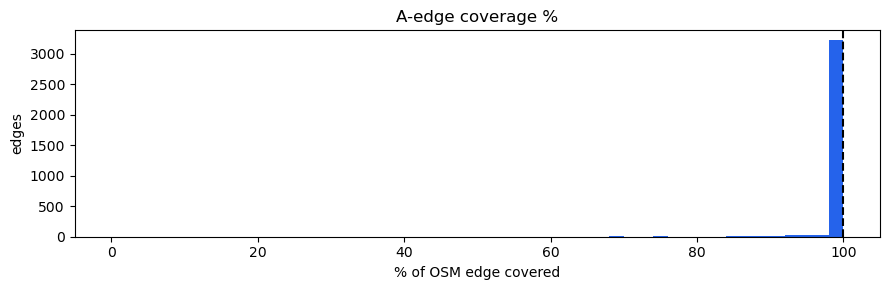


ABNORMAL — worst-covered A-edges:


,source_id,overlap_pct,dtw_distance,n_edges,matched_len
3345,3906,0,0.499328,1,0.000000
665,757,0,0.660371,1,0.000000
528,600,39,2.013272,1,0.000000
2728,3168,41,2.421992,1,7.628138
1864,2141,54,1.254755,2,7.126201
2247,2604,54,2.346286,1,10.000000
1151,1316,55,3.858585,2,18.183348
327,379,58,0.353107,1,13.742746
3158,3689,61,0.210245,1,16.077189
1544,1777,65,2.794182,1,7.579124


In [2]:
acov = matched["overlap_pct"].astype("float")
print(f"A coverage %:  median={acov.median():.1f}  mean={acov.mean():.1f}  min={acov.min():.0f}")
print(f"  >= 99%: {(acov>=99).mean()*100:.1f}%   < 95%: {(acov<95).sum()} edges   < 90%: {(acov<90).sum()} edges")
plt.figure(figsize=(9,3)); plt.hist(acov, bins=np.arange(0,102,2), color="#2563eb"); plt.axvline(100,color="k",ls="--")
plt.title("A-edge coverage %"); plt.xlabel("% of OSM edge covered"); plt.ylabel("edges"); plt.tight_layout(); plt.show()
print("\nABNORMAL — worst-covered A-edges:")
display(matched.sort_values("overlap_pct").head(10)[["source_id","overlap_pct","dtw_distance","n_edges","matched_len"]])


## 2. B-edge usage per route-edge (% of each NVDB edge consumed)

Interior route-edges should be ~100 %; the **first/last** edge of a route is naturally partial
(the route enters/exits mid-edge), so those are expected below 100.

  interior : n=  686  median used%=100.0  <90%=48
  first    : n= 1329  median used%= 24.8  <90%=1024
  last     : n= 1329  median used%= 27.8  <90%=985
  single   : n= 2054  median used%= 27.2  <90%=1745


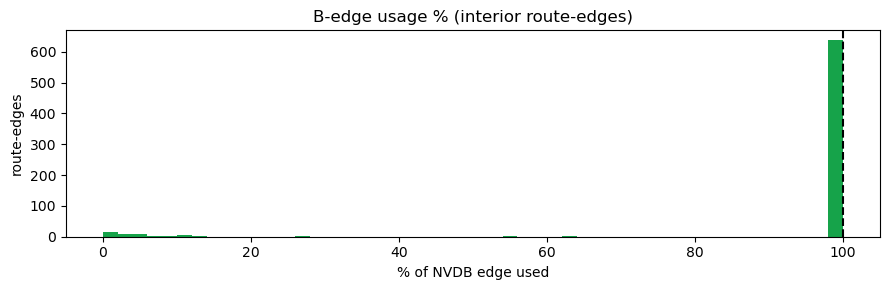


ABNORMAL — interior route-edges poorly used (<90%):


,source_id,dest_id,seq,edge_b_used_pct,edge_matched_len,edge_b_len,edge_match_dist_avg
1327,930,1167,4,0.2,0.543537,331.096476,3.218060
3677,2612,949,1,0.2,0.926413,381.836563,2.482376
2535,1766,1709,1,0.4,0.161626,36.396378,2.236078
4906,3563,2212,1,0.5,2.220853,437.633111,3.280295
2865,1999,2082,1,0.7,1.222312,175.445948,0.421121
5171,3774,2082,1,0.7,1.222312,175.445948,0.668126
1836,1278,532,1,0.9,0.985980,104.605663,1.060670
1786,1254,2417,1,1.0,2.507179,259.032512,1.498296
4516,3255,2336,1,1.1,2.819369,253.827791,12.214058
1876,1306,2336,1,1.1,2.819369,253.827791,13.898793


In [3]:
rl = routes_long.copy()
rl["pos"] = np.where(rl.seq==0, "first", np.where(rl.seq==rl.n_edges-1, "last", "interior"))
rl.loc[rl.n_edges==1, "pos"] = "single"
for pos in ["interior","first","last","single"]:
    s = rl.loc[rl.pos==pos, "edge_b_used_pct"]
    if len(s): print(f"  {pos:9s}: n={len(s):5d}  median used%={s.median():5.1f}  <90%={ (s<90).sum() }")
plt.figure(figsize=(9,3))
plt.hist(rl.loc[rl.pos=='interior','edge_b_used_pct'], bins=np.arange(0,102,2), color="#16a34a")
plt.axvline(100,color="k",ls="--"); plt.title("B-edge usage % (interior route-edges)")
plt.xlabel("% of NVDB edge used"); plt.ylabel("route-edges"); plt.tight_layout(); plt.show()
print("\nABNORMAL — interior route-edges poorly used (<90%):")
display(rl[(rl.pos=='interior')&(rl.edge_b_used_pct<90)]
        .sort_values("edge_b_used_pct").head(10)
        [["source_id","dest_id","seq","edge_b_used_pct","edge_matched_len","edge_b_len","edge_match_dist_avg"]])


## 3. B-edge usage aggregated per NVDB edge (gaps & contention)

For each NVDB edge, total matched length ÷ its length across **all** routes:
- ~100 % → fully and uniquely used (good).
- **> 100 %** → claimed by overlapping A-routes (**contention** — the same NVDB geometry matched
  to several OSM edges over the same stretch). Abnormal.
- low → mostly unmatched.

NVDB edges used: 2109
  used% median=100.0
  contested (used by >1 OSM edge): 1182
  over-used (>110%): 727   barely used (<25%): 58


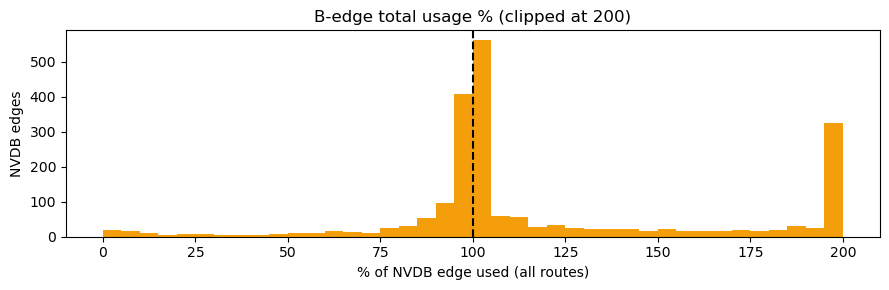


ABNORMAL — over-used / contested NVDB edges:


,dest_id,used_len,b_len,n_a_edges,used_pct
1550,1852,347.813731,86.149333,8,403.733514
423,556,7.690609,1.922652,4,400.000000
1258,1534,5.123996,1.280999,4,400.000000
1509,1807,18.176449,4.544112,4,400.000000
1686,1998,6.976049,1.744012,4,400.000000
1169,1422,14.134846,3.533712,4,400.000000
1785,2106,115.594058,28.919639,4,399.707823
424,557,775.549363,195.191462,5,397.327504
1445,1736,529.795274,138.124004,6,383.564955
1546,1848,42.714595,11.388524,6,375.067010


In [4]:
bagg = (routes_long.groupby("dest_id")
        .agg(used_len=("edge_matched_len","sum"), b_len=("edge_b_len","first"),
             n_a_edges=("source_id","nunique"))
        .reset_index())
bagg["used_pct"] = 100*bagg.used_len/bagg.b_len
print(f"NVDB edges used: {len(bagg)}")
print(f"  used% median={bagg.used_pct.median():.1f}")
print(f"  contested (used by >1 OSM edge): {(bagg.n_a_edges>1).sum()}")
print(f"  over-used (>110%): {(bagg.used_pct>110).sum()}   barely used (<25%): {(bagg.used_pct<25).sum()}")
plt.figure(figsize=(9,3)); plt.hist(bagg.used_pct.clip(0,200), bins=np.arange(0,205,5), color="#f59e0b")
plt.axvline(100,color="k",ls="--"); plt.title("B-edge total usage % (clipped at 200)")
plt.xlabel("% of NVDB edge used (all routes)"); plt.ylabel("NVDB edges"); plt.tight_layout(); plt.show()
print("\nABNORMAL — over-used / contested NVDB edges:")
display(bagg.sort_values("used_pct", ascending=False).head(10))


## 4. Match-distance quality

match distance (m): median=2.64  p90=31.23  p99=90.43  max=389.92
  > 10 m: 853 edges    > 25 m: 463 edges


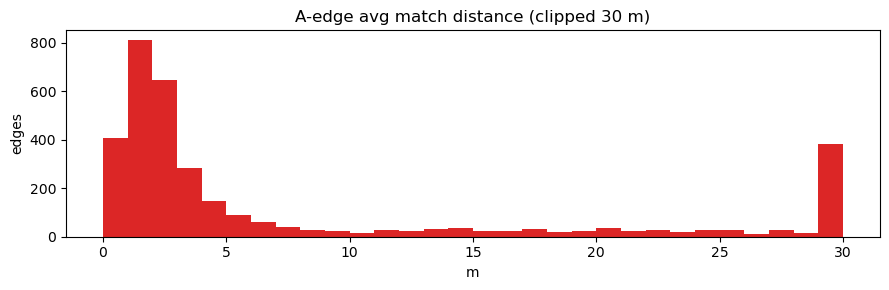


ABNORMAL — highest-drift matches:


,source_id,dest_ids,dtw_distance,bearing_diff,overlap_pct,n_edges
554,634,"[918, 2105, 2106, 1746]",389.923922,74.633014,100,4
2352,2728,"[1746, 2106, 2105, 918]",381.787324,74.130781,100,4
1440,1668,[922],363.775638,3.648741,100,1
3019,3535,[2109],359.587283,3.648741,100,1
1288,1479,[2139],308.028031,60.112780,100,1
2908,3389,[2139],303.099973,60.112780,100,1
2090,2408,[2093],277.333138,30.980182,99,1
201,222,[2093],267.315899,30.724486,100,1
2333,2701,[1848],178.541753,22.346008,100,1
526,598,[1848],176.068712,22.346008,100,1


In [5]:
d = matched["dtw_distance"]
print(f"match distance (m): median={d.median():.2f}  p90={d.quantile(.9):.2f}  p99={d.quantile(.99):.2f}  max={d.max():.2f}")
print(f"  > 10 m: {(d>10).sum()} edges    > 25 m: {(d>25).sum()} edges")
plt.figure(figsize=(9,3)); plt.hist(d.clip(0,30), bins=np.arange(0,31,1), color="#dc2626")
plt.title("A-edge avg match distance (clipped 30 m)"); plt.xlabel("m"); plt.ylabel("edges"); plt.tight_layout(); plt.show()
print("\nABNORMAL — highest-drift matches:")
display(matched.sort_values("dtw_distance", ascending=False).head(10)
        [["source_id","dest_ids","dtw_distance","bearing_diff","overlap_pct","n_edges"]])


## 5. Abnormal-data summary (saved to `output/`)

In [6]:
issues = []
for _, r in matched.iterrows():
    flags = []
    if float(r.overlap_pct) < 95: flags.append("A_under_covered")
    if r.dtw_distance > 25:       flags.append("high_drift")
    if r.bearing_diff > 45:       flags.append("bearing_off")
    if flags:
        issues.append({"source_id": r.source_id, "dest_ids": r.dest_ids,
                       "overlap_pct": r.overlap_pct, "dtw_distance": round(r.dtw_distance,2),
                       "bearing_diff": round(r.bearing_diff,1), "flags": ";".join(flags)})
issues = pd.DataFrame(issues)
over = bagg[(bagg.used_pct>110)].assign(flag="B_over_used")[["dest_id","used_pct","n_a_edges","flag"]]
os.makedirs("../output", exist_ok=True)
issues.to_csv("../output/validation_a_issues.csv", index=False)
over.to_csv("../output/validation_b_overused.csv", index=False)
print(f"A-edge issues: {len(issues)}  -> output/validation_a_issues.csv")
print(f"B-edge over-used: {len(over)}  -> output/validation_b_overused.csv")
print("\nA-edge issue breakdown:")
print(issues["flags"].value_counts() if len(issues) else "none")
display(issues.head(15))


A-edge issues: 897  -> output/validation_a_issues.csv
B-edge over-used: 727  -> output/validation_b_overused.csv

A-edge issue breakdown:
flags
bearing_off               318
high_drift;bearing_off    268
high_drift                195
A_under_covered           116
Name: count, dtype: int64


,source_id,dest_ids,overlap_pct,dtw_distance,bearing_diff,flags
0,33,[1229],93,1.31,0.0,A_under_covered
1,36,[599],100,47.38,6.5,high_drift
2,38,[1861],100,16.22,89.2,bearing_off
3,41,[2330],100,13.68,54.5,bearing_off
4,53,[2084],100,55.01,84.7,high_drift;bearing_off
5,59,[1123],100,22.41,86.5,bearing_off
6,63,[9],100,54.47,79.0,high_drift;bearing_off
7,68,[1960],100,25.72,73.1,high_drift;bearing_off
8,70,[850],100,29.20,57.5,high_drift;bearing_off
9,76,[1174],100,70.15,59.3,high_drift;bearing_off
